# Convolutional Neural Networks (CNN)

# **Assignment 2**
### 10 Points

---

#### The lab has two parts. 

The first part of the lab acts as a tutorial for you to get familiar with PyTorch CNN. 

In the second part you will have to do some real coding:


1. Construct a CNN model. [1 point]

2. Define the Loss, training device, and any hyperparameters that you wish to tune. [1 point]

3. Define a training function that trains the model using training set and test it with testing set. [2 points]

4. Train the customized model on CIFAR-10 dataset and ensure the model is trained correctly (fine-tune). [2 points]

5. Visualize the loss and accuracy of the model. [1 point]

6. Load a pre-trained CNN model and freeze the pre-trained weights. [1 point]

7. Replace the final classifier layer (Linear layer) to match the number of classes in the dataset. [1 point]

8. Train the pre-trained model and visualize the accuracy and loss. [1 point]
---



This lab expects a basic understanding of pytorch and convolutional networks.

* `torch.nn` documentation http://pytorch.org/docs/master/nn.html
* Convolution animations. Make sure to understand these animations so you can visualize stride, padding, etc. https://github.com/vdumoulin/conv_arithmetic/blob/master/README.md
* If you want to look at something more complicated, check out the ResNet implementation in torchvision: https://github.com/pytorch/vision/blob/master/torchvision/models/resnet.py

In [1]:
import torch
import torch.nn.functional as F
from torch import autograd, nn
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms, datasets

## Data Format

Dimension ordering is very important. For pytorch:

* 2D data like images should be `(samples, channels, height, width)` sometimes called "NCHW" or "channels first"
* 1D data like stock prices should be `(samples, channels, time)`
* 2D filters should be `(out_channels, in_channels, height, width)`
* 1D filters should be `(out_channels, in_channels, time)`

Different frameworks (e.g., TensorFlow) use different dimension orderings so be very careful, especially when implementing code or reading data targeted at a different framework.

Note most image data is RGB but some is BGR  or ARGB.

In [2]:
input_image = autograd.Variable(torch.randn(1,3,32,32)) # single 32x32 RGB image
print(input_image.size())
input_signal = autograd.Variable(torch.randn(1,40,100)) # 40 dimensional signal for 100 timesteps
print(input_signal.size())

torch.Size([1, 3, 32, 32])
torch.Size([1, 40, 100])


## Convolutional Layers

The `torch.nn` module provides layers for CNNs. Use in the same way as other modules. Please refer to the documentation for details. Some of the most common layers you will use:

* `torch.nn.Conv2d`
* `torch.nn.ConvTranspose2d`
* `torch.nn.MaxPool2d`
* `torch.nn.AvgPool2d`


In [3]:
# Create layers
layer_c2d = torch.nn.Conv2d(in_channels=3, out_channels=20, kernel_size=5, stride=1, padding=2)
layer_avg = torch.nn.AvgPool2d(kernel_size=32)

In [4]:
# Use layers directly
y = layer_c2d(input_image)
print(y.size())

torch.Size([1, 20, 32, 32])


In [5]:
# Add layers to model
model = torch.nn.Sequential(layer_avg, layer_c2d)
y = model(input_image)
print(y.size())

torch.Size([1, 20, 1, 1])


## Convolutional Functions

The `torch.nn.functional` module provides low-level functions. Depending on what kinds of models you are making, you may never have to use these functions, and use pre-made layers instead. When using the functional module, you need to instantiate parameters yourself.

http://pytorch.org/docs/0.1.12/nn.html#torch-nn-functional

Example low-level functions:

* `F.max_pool2d`
* `F.dropout2d`
* `F.conv2d`

In [6]:
filters = autograd.Variable(torch.randn(20,3,5,5)) # 5x5 filter from 3 dimensions to 20
y=F.conv2d(input_image, filters, padding=2)
print(y.size())

torch.Size([1, 20, 32, 32])


In [7]:
filters = autograd.Variable(torch.randn(256,40,5)) # 5 wide filter from 40 dimensions to 256
y=F.conv1d(input_signal, filters, padding=2)
print(y.size())

torch.Size([1, 256, 100])


For example, if you generate the kernel using a neural network, you will have to use the functional module instead of a standard convolutional layer.

## Padding

Simple 0-padding can be accomplished using the `padding` keyword argument of many functions. Normally, you will be using the same vertical and horizontal padding but you can also pass a tuple `(H,W)`. Padding is applied symmetrically.

In [8]:
inputs = autograd.Variable(torch.randn(1,3,32,32)) # single 32x32 RGB image
print(torch.nn.Conv2d(in_channels=3, out_channels=20, kernel_size=7, padding=0)(inputs).size())
print(torch.nn.Conv2d(in_channels=3, out_channels=20, kernel_size=7, padding=1)(inputs).size())
print(torch.nn.Conv2d(in_channels=3, out_channels=20, kernel_size=7, padding=2)(inputs).size())
print(torch.nn.Conv2d(in_channels=3, out_channels=20, kernel_size=7, padding=3)(inputs).size())
print(torch.nn.Conv2d(in_channels=3, out_channels=20, kernel_size=7, padding=(0,3))(inputs).size())

torch.Size([1, 20, 26, 26])
torch.Size([1, 20, 28, 28])
torch.Size([1, 20, 30, 30])
torch.Size([1, 20, 32, 32])
torch.Size([1, 20, 26, 32])


For more complicated padding, use a padding layer before your convolution.

* Single int: apply to all sides
* tuple (H,W): apply H to top and bottom, W to left and right
* tuple (left, right, top, bottom)

In [9]:
inputs = autograd.Variable(torch.randn(1,3,32,32)) # single 32x32 RGB image
y = torch.nn.Conv2d(3, 20, 7)(torch.nn.ReplicationPad2d(3)(inputs))
print(y.size())

torch.Size([1, 20, 32, 32])


Common padding layers:

* torch.nn.ReplicationPad2d
* torch.nn.ReflectionPad2d
* torch.nn.ZeroPad2d
* torch.nn.ConstantPad2d

## Normalization and Dropout

Don't forget BatchNorm2d and Dropout2d if you want to improve performance!

In [10]:
h = nn.Conv2d(3, 20, 5, padding=2)(input_image)
h = nn.BatchNorm2d(20)(h)
h = F.relu(h)
h = nn.Dropout2d(0.5)(h)
print(h.size())

torch.Size([1, 20, 32, 32])


## Downsampling

You can downsample using pooling operations or strided convolutions.

In [11]:
# Simple pooling operations
print(nn.MaxPool2d(2)(input_image).size())
print(nn.AvgPool2d(2)(input_image).size())

torch.Size([1, 3, 16, 16])
torch.Size([1, 3, 16, 16])


In [12]:
# Strided convolution
layer = torch.nn.Conv2d(in_channels=3, out_channels=20, kernel_size=5, stride=2, padding=2)
print(layer(input_image).size())

torch.Size([1, 20, 16, 16])


## Reading Image Data

### The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. 

### There are 50000 training images and 10000 test images.

In [13]:
## load training dataset
BATCH_SIZE = 512

Mytransform = transforms.Compose([transforms.ToTensor(),transforms.RandomHorizontalFlip(p=0.3)])

trainset = torchvision.datasets.CIFAR10(root='data/train', train=True,
                                        download=True, transform=Mytransform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=0)

## download and load testing dataset
testset = torchvision.datasets.CIFAR10(root='data/test', train=False,
                                       download=True, transform=Mytransform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE,
                                         shuffle=False, num_workers=0)

print('==>>> total training set number: {}'.format(len(trainset)))
print('==>>> total test set number: {}'.format(len(testset)))

==>>> total training set number: 50000
==>>> total test set number: 10000


### Visualizing the CIFAR-10 dataset

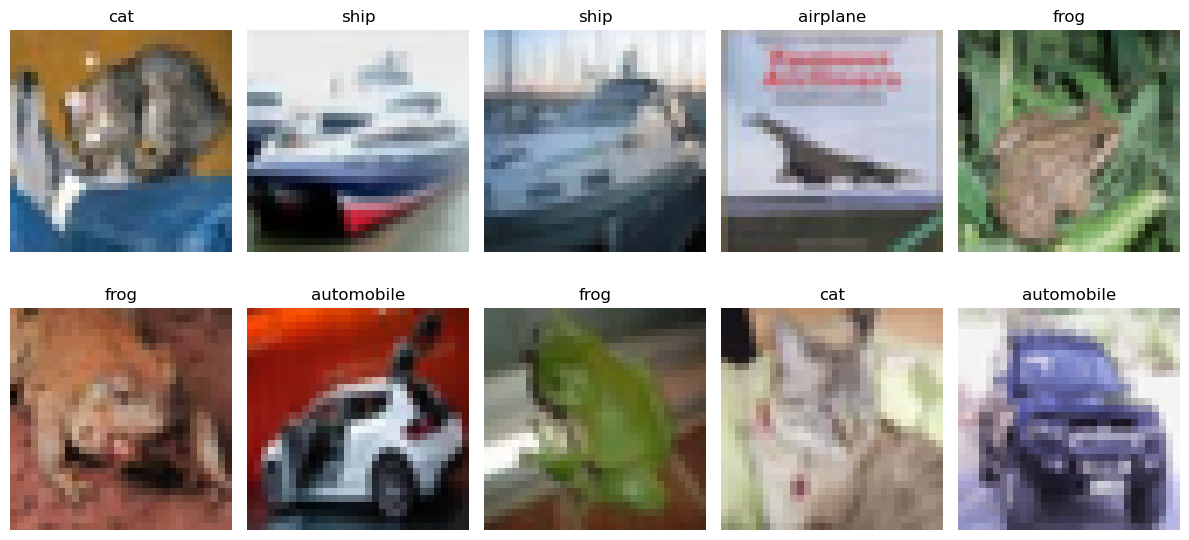

In [14]:
import matplotlib.pyplot as plt

# Define the class labels
class_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Get a batch of images from the test dataset
images, labels = next(iter(testloader))

# Plot the images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

# Ensure the loop does not exceed the number of axes available
for i in range(min(len(images), len(axes))):  # This ensures we don't go out of bounds
    image = images[i].numpy().transpose((1, 2, 0))
    # If you've applied normalization, ensure to denormalize the image here
    label = class_labels[labels[i].item()]
    
    axes[i].imshow(image)
    axes[i].set_title(label)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


# Coding Task 1

## Now write a piece of code to train a CNN Model using CIFAR10 images. 

You are encouraged to reuse your code from Assignment 1.

Another useful blog for this assignment would be https://www.analyticsvidhya.com/blog/2021/09/convolutional-neural-network-pytorch-implementation-on-cifar10-dataset/.


## Define your network architecture. [1 point]

Create an instance of the MyCNN model. The model should process 32 × 32 RGB images and begins with a convolutional layer that takes 3 input channels and produces 64 feature maps using a 3 × 3 kernel.

The feature maps should then be passed through a fully connected layer with a single hidden layer. The final output layer contains 10 neurons, representing the 10 classes in the classification task.

In [15]:
class Mycnn(nn.Module):
    def __init__(self):
        super(Mycnn, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3) # convolutional layer
        self.fc1 = nn.Linear(64 * 30 * 30, 256) #  64 feature maps * (30 * 30 pixels) * hidden layer with 256 neuron
        self.fc2 = nn.Linear(256, 10) # must output 10 classes

    def forward(self, x):

        x = F.relu(self.conv1(x)) # apply convolution then ReLU
        x = x.view(x.size(0), -1) # flatten feature maps
        x = F.relu(self.fc1(x)) # hidden layer
        x = self.fc2(x) # output layer
        
        return x
    
model = Mycnn()

## Define the Loss, training device, and any hyperparameters that you wish to tune. [1 point]

Since this is a classification task, use Cross Entropy Loss (torch.nn.CrossEntropyLoss) as the loss function. Also check the available device (CPU or GPU) and move the model to that device before training.

In [16]:
loss_function = nn.CrossEntropyLoss()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Define a training function that trains the model using training set and test it with testing set. [2 points]

Similar to assignment 1, the training function should:
- The function should be able to train the model for N epochs and validate the model on the test set after each epoch. 
- The function should print the loss and accuracy on the training set and test set after each epoch. 
- The function should store and return lists containing the loss and accuracy history on the training set and test set, so we can print the plot of accuracy and loss. 

In [17]:
def train_model(model, train_loader, test_loader, criterion, optimizer, n_epochs):
    
    # Initialize lists
    train_acc_list = []
    valid_acc_list = []
    train_loss_list = []
    valid_loss_list = []

    model.to(device)

    for epoch in range(n_epochs):
        
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * data.size(0)
            _, predicted = torch.max(output.data, 1)
            train_correct += (predicted == target).sum().item()
            
        # Validation
        model.eval()
        valid_loss = 0.0
        valid_correct = 0
        
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)
                
                valid_loss += loss.item() * data.size(0)
                _, predicted = torch.max(output.data, 1)
                valid_correct += (predicted == target).sum().item()

        # Calculate Averages
        train_loss = train_loss/len(train_loader.dataset)
        train_acc = 100.*train_correct/len(train_loader.dataset)
        valid_loss = valid_loss/len(test_loader.dataset)
        valid_acc = 100.*valid_correct/len(test_loader.dataset)

        # Print values after each epoch
        print(f'Epoch {epoch+1}/{n_epochs}:')
        print(f'\tTrain Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.2f}%')
        print(f'\tValidation Loss: {valid_loss:.4f} | Validation Accuracy: {valid_acc:.2f}%')

        # Add values to lists for plotting
        train_loss_list.append(train_loss)
        train_acc_list.append(train_acc)
        valid_loss_list.append(valid_loss)
        valid_acc_list.append(valid_acc)

    return train_acc_list, valid_acc_list, train_loss_list, valid_loss_list

## Train the customized model on CIFAR-10 dataset and ensure the model is trained correctly (fine-tune). [2 points]

Train and test your network in a loop, while keeping track of the **losses and accuracy**.   

In [18]:
n_epochs = 10

model = Mycnn().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_acc, valid_acc, train_loss, valid_loss = train_model(model, trainloader, testloader, loss_function, optimizer, n_epochs)

Epoch 1/10:
	Train Loss: 2.0279 | Train Accuracy: 35.68%
	Validation Loss: 1.4888 | Validation Accuracy: 47.38%
Epoch 2/10:
	Train Loss: 1.3918 | Train Accuracy: 51.02%
	Validation Loss: 1.3354 | Validation Accuracy: 52.09%
Epoch 3/10:
	Train Loss: 1.2569 | Train Accuracy: 55.73%
	Validation Loss: 1.2348 | Validation Accuracy: 56.23%
Epoch 4/10:
	Train Loss: 1.1683 | Train Accuracy: 59.17%
	Validation Loss: 1.1939 | Validation Accuracy: 57.83%
Epoch 5/10:
	Train Loss: 1.1030 | Train Accuracy: 61.53%
	Validation Loss: 1.1689 | Validation Accuracy: 58.87%
Epoch 6/10:
	Train Loss: 1.0561 | Train Accuracy: 63.09%
	Validation Loss: 1.1420 | Validation Accuracy: 59.83%
Epoch 7/10:
	Train Loss: 0.9978 | Train Accuracy: 65.14%
	Validation Loss: 1.1056 | Validation Accuracy: 60.98%
Epoch 8/10:
	Train Loss: 0.9607 | Train Accuracy: 66.52%
	Validation Loss: 1.0893 | Validation Accuracy: 62.24%
Epoch 9/10:
	Train Loss: 0.9211 | Train Accuracy: 68.02%
	Validation Loss: 1.0678 | Validation Accuracy:

## Visualize the loss and accuracy of the model. [1 point]

### Plot the graph of the training accuracy and validation accuracy

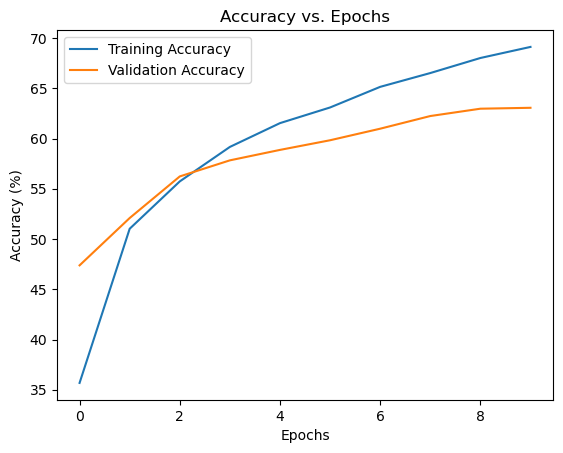

In [19]:
plt.plot(train_acc, label='Training Accuracy')
plt.plot(valid_acc, label='Validation Accuracy')

plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')

plt.legend()
plt.show()

### Plot the graph of the training loss and validation loss

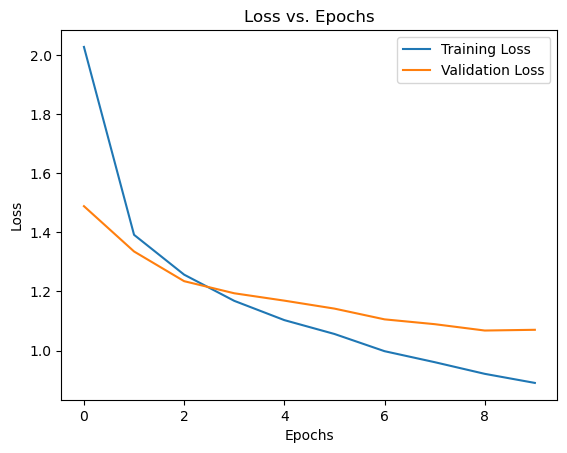

In [20]:
plt.plot(train_loss, label='Training Loss')
plt.plot(valid_loss, label='Validation Loss')

plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

## Pre-trained models

Training CNN models from scratch requires a lot of data. Hence we often use pre-trained models to alleviate this problem. For CNNs, pre-trained models are readily available for famous architectures such as VGG, ResNet and Inception Net.

When you set `pretrained=True`, torchvision automatically downloads the model for you, and initializes weights from there. If this does not work, run the following:
```
>> wget https://download.pytorch.org/models/vgg16-397923af.pth
>> mv vgg16-397923af.pth ~/.torch/models/vgg16-397923af.pth
```

You can find other pretrained models included at https://pytorch.org/docs/stable/torchvision/models.html.

In [21]:
import torchvision.models as models

vgg16 = models.vgg16(pretrained=True) # this might take a while
vgg16.eval()
print(vgg16)

/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

We can build a VGG feature extractor. These are often useful in downstream tasks, for example learning deep visual semantic embeddings (https://static.googleusercontent.com/media/research.google.com/en//pubs/archive/41473.pdf). This allows us to use features trained on large datasets like ImageNet, and use on tasks which have lesser data.

``` vgg16.features ``` gives us convolutional features. Often, even taking all the layers until the last classification layer also suffices.


In [22]:
vgg16_feature_extractor = vgg16.features
# print('VGG feature extractor', vgg16_feature_extractor)
print(vgg16_feature_extractor(Variable(torch.rand(1, 3, 224, 224))).size())
print(vgg16_feature_extractor(Variable(torch.rand(1, 3, 224, 224))).view(1, -1).size()) # flatten conv features

torch.Size([1, 512, 7, 7])
torch.Size([1, 25088])


# Coding Task 2 

Please see below the section on Pre-Trained Models and how they can be used as feature extractors. 

You should now use any pre-trained model such as the one shown below and extract features of an image of your choice and develop a simple  classifer using softmax, MLP or any other one you may want. Keep in mind the input image size before training your model.

A useful blog post for completing this piece of code would be https://medium.com/@tsakunelsonz/loading-and-training-a-neural-network-with-custom-dataset-via-transfer-learning-in-pytorch-8e672933469



## Load a pre-trained CNN model and freeze the pre-trained weights. [1 point]
## Replace the final classifier layer (Linear layer) to match the number of classes in the dataset. [1 point]

In [23]:
import torchvision.models as models

# Use resnet18 with default weights
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze weights
for param in resnet.parameters():
    param.requires_grad = False

# We replace last with a linear layer corresponding to our 10 classes
resnet.fc = nn.Linear(resnet.fc.in_features, 10)

## Train the pre-trained model and visualize the accuracy and loss. [1 point]

Train and test the pre-trained network in a loop, while keeping track of the **losses and accuracy**.   

In [24]:
resnet.to(device)
optimizer_r = torch.optim.Adam(resnet.fc.parameters(), lr=0.001)

r_train_acc, r_valid_acc, r_train_loss, r_valid_loss = train_model(resnet, trainloader, testloader, loss_function, optimizer_r, n_epochs)

Epoch 1/10:
	Train Loss: 1.8954 | Train Accuracy: 33.82%
	Validation Loss: 1.6953 | Validation Accuracy: 42.32%
Epoch 2/10:
	Train Loss: 1.6479 | Train Accuracy: 43.13%
	Validation Loss: 1.6353 | Validation Accuracy: 44.36%
Epoch 3/10:
	Train Loss: 1.5976 | Train Accuracy: 44.98%
	Validation Loss: 1.5960 | Validation Accuracy: 45.39%
Epoch 4/10:
	Train Loss: 1.5726 | Train Accuracy: 45.92%
	Validation Loss: 1.5871 | Validation Accuracy: 45.57%
Epoch 5/10:
	Train Loss: 1.5561 | Train Accuracy: 46.19%
	Validation Loss: 1.5737 | Validation Accuracy: 46.14%
Epoch 6/10:
	Train Loss: 1.5469 | Train Accuracy: 46.39%
	Validation Loss: 1.5848 | Validation Accuracy: 44.78%
Epoch 7/10:
	Train Loss: 1.5341 | Train Accuracy: 46.87%
	Validation Loss: 1.5732 | Validation Accuracy: 45.78%
Epoch 8/10:
	Train Loss: 1.5318 | Train Accuracy: 47.17%
	Validation Loss: 1.5523 | Validation Accuracy: 46.83%
Epoch 9/10:
	Train Loss: 1.5264 | Train Accuracy: 47.28%
	Validation Loss: 1.5589 | Validation Accuracy:

### Plot the graph of the training accuracy and validation accuracy

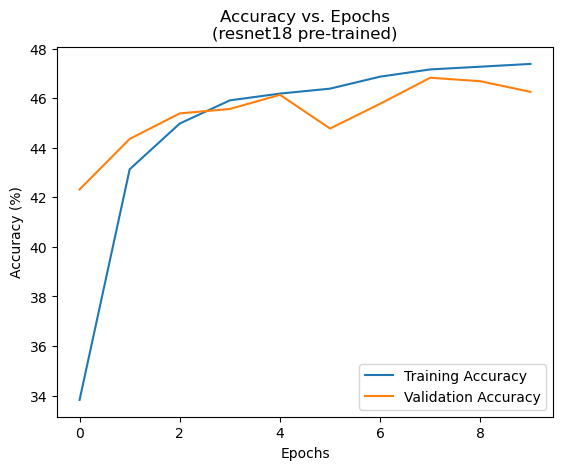

In [25]:
plt.plot(r_train_acc, label='Training Accuracy')
plt.plot(r_valid_acc, label='Validation Accuracy')

plt.title('Accuracy vs. Epochs\n(resnet18 pre-trained)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')

plt.legend()
plt.show()

### Plot the graph of the training loss and validation loss

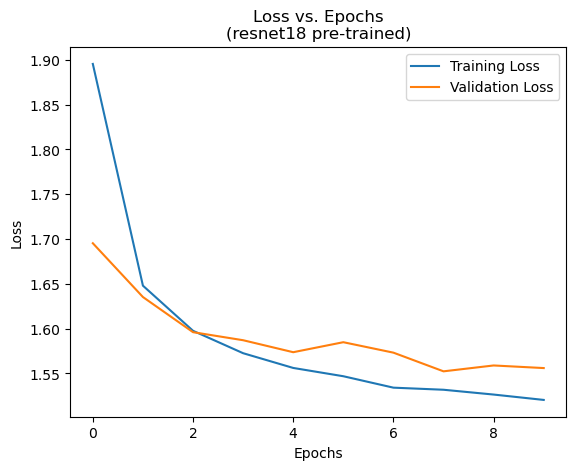

In [26]:
plt.plot(r_train_loss, label='Training Loss')
plt.plot(r_valid_loss, label='Validation Loss')

plt.title('Loss vs. Epochs\n(resnet18 pre-trained)')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()